<a href="https://colab.research.google.com/github/SSClements/INDE2000-Project/blob/main/INDE2000_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Library used**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Holt-Winters!!
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Data**

In [4]:
file_names = [
    'data/2010-2011 Solar home electricity data.csv',
    'data/2011-2012 Solar home electricity data v2.csv',
    'data/2012-2013 Solar home electricity data v2.csv'
]

all_years_list = []

for name in file_names:

    try:
        # header=1 to skip the PDF description row
        temp_df = pd.read_csv(name, header=1)

        # Clean column names just in case
        temp_df.columns = [str(col).strip().lower() for col in temp_df.columns]

        # Find 'Date' and 'Category' by position or keyword
        date_col = next((c for c in temp_df.columns if 'date' in c), None)
        cat_col = next((c for c in temp_df.columns if 'consumption' in c or 'category' in c), None)

        if not date_col or not cat_col:
            print(f"Skipping {name}: Missing Date/Category columns.")
            continue

        # Select 48 columns by position (The last 48 columns)
        # In Ausgrid files, the 48 half-hour slots are always the last 48 columns.
        # Take the last 48 columns and rename them to 1-48 for consistency.
        power_data_cols = temp_df.columns[-48:].tolist()

        # Filter for General Consumption (GC)
        temp_gc = temp_df[temp_df[cat_col].astype(str).str.contains('GC', case=False, na=False)].copy()

        # Ensure data is numeric
        for col in power_data_cols:
            temp_gc[col] = pd.to_numeric(temp_gc[col], errors='coerce')

        # Aggregate: Mean of ALL customers
        daily_avg = temp_gc.groupby(date_col)[power_data_cols].mean().reset_index()

        # Rename columns to standard: 'Date', '1', '2', ..., '48'
        standard_names = ['Date'] + [str(i) for i in range(1, 49)]
        daily_avg.columns = standard_names

        all_years_list.append(daily_avg)
        print(f"SUCCESS: Processed {name} with 48 time slots.")

        del temp_df, temp_gc

    except Exception as e:
        print(f"Error at {name}: {e}")


Error at data/2010-2011 Solar home electricity data.csv: [Errno 2] No such file or directory: 'data/2010-2011 Solar home electricity data.csv'
Error at data/2011-2012 Solar home electricity data v2.csv: [Errno 2] No such file or directory: 'data/2011-2012 Solar home electricity data v2.csv'
Error at data/2012-2013 Solar home electricity data v2.csv: [Errno 2] No such file or directory: 'data/2012-2013 Solar home electricity data v2.csv'


# **Transformation, Deseasonalization and Visualization**

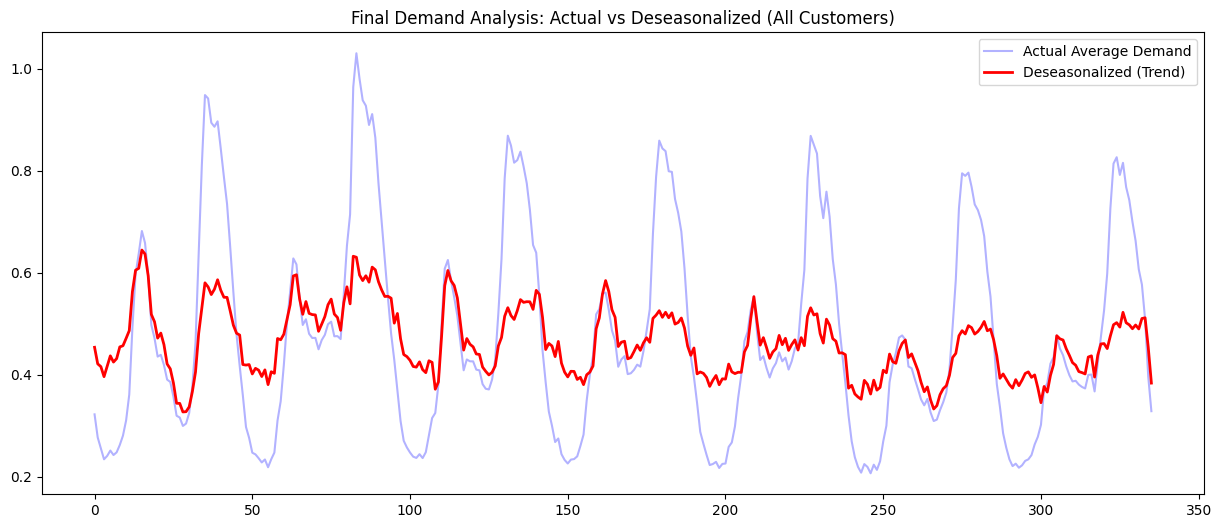

In [17]:
if all_years_list:
    df_combined = pd.concat(all_years_list, ignore_index=True)

    # Transformation
    time_periods = [str(i) for i in range(1, 49)]
    df_long = df_combined.melt(id_vars=['Date'], value_vars=time_periods,
                               var_name='Period', value_name='Avg_kWh')

    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)
    df_long['Period'] = df_long['Period'].astype(int)
    df_long = df_long.sort_values(['Date', 'Period']).reset_index(drop=True)

    # Deseasonalization (Lecture 6)
    grand_mean = df_long['Avg_kWh'].mean()
    seasonal_indices = df_long.groupby('Period')['Avg_kWh'].mean() / grand_mean
    df_long['Seasonal_Index'] = df_long['Period'].map(seasonal_indices)
    df_long['Deseasonalized_kWh'] = df_long['Avg_kWh'] / df_long['Seasonal_Index']

    # Visualization
    plt.figure(figsize=(15, 6))
    plt.plot(df_long['Avg_kWh'][:336], label='Actual Average Demand', color='blue', alpha=0.3)
    plt.plot(df_long['Deseasonalized_kWh'][:336], label='Deseasonalized (Trend)', color='red', linewidth=2)
    plt.title('Final Demand Analysis: Actual vs Deseasonalized (All Customers)')
    plt.legend()
    plt.show()
else:
    print("Check if your files are actually .csv and have 48 data columns at the end.")

In [1]:
# Counting NA values for total data
na_count = df_long['Avg_kWh'].isna().sum()
total_count = len(df_long)
na_pct = (na_count / total_count) * 100
print(f"Missing values (NA): {na_count} out of {total_count} ({nan_pct:.2f}%)")

# Document Data
## Total Entries, Missing Data, Percentage
for i, df in enumerate(all_years_list):
    year_label = file_names[i].split('/')[-1][:9]

    non_missing = df.iloc[:, 1:].count().sum()
    total_cells = df.iloc[:, 1:].size
    missing = total_cells - non_missing
    missing_pct = (missing / total_cells) * 100

    print(f"  {year_label} | Total: {total_cells} | Missing: {missing} | ({missing_pct:.2f}%)")


NameError: name 'df_long' is not defined

In [21]:
# Outliers
mean_val = df_long['Deseasonalized_kWh'].mean()
std_val = df_long['Deseasonalized_kWh'].std()
outliers = df_long[(df_long['Deseasonalized_kWh'] < mean_val - 3*std_val) |
                   (df_long['Deseasonalized_kWh'] > mean_val + 3*std_val)]

total_count = len(df_long)
print(f"Outliers (±3 std): {len(outliers)} out of {total_count} ({(len(outliers)/total_count)*100:.2f}%)")



Outliers (±3 std): 631 out of 52608 (1.20%)


In [24]:
print(outliers[['Date', 'Period', 'Avg_kWh', 'Deseasonalized_kWh']].sort_values('Deseasonalized_kWh', ascending=False).head(20))

            Date  Period   Avg_kWh  Deseasonalized_kWh
10541 2011-02-05      30  1.286773            1.385441
10540 2011-02-05      29  1.235820            1.349161
10542 2011-02-05      31  1.300290            1.347914
10539 2011-02-05      28  1.210897            1.317120
10538 2011-02-05      27  1.203817            1.295787
10543 2011-02-05      32  1.329047            1.291208
10537 2011-02-05      26  1.166850            1.254165
10536 2011-02-05      25  1.118087            1.192858
10544 2011-02-05      33  1.334213            1.169576
10535 2011-02-05      24  1.071133            1.155227
44764 2013-01-18      29  1.010530            1.103209
10534 2011-02-05      23  0.985903            1.079880
44765 2013-01-18      30  1.000880            1.077626
10585 2011-02-06      26  0.989167            1.063186
44766 2013-01-18      31  1.002337            1.039048
10584 2011-02-06      25  0.969457            1.034289
44285 2013-01-08      30  0.949737            1.022561
44763 2013

Outliers are during peak summer season, keep them in